# Conceptual Modeling `geoPFA`: 3D Example from Newberry Volcano, OR
This notebook continues the `geoPFA` tutorial series, picking up from the component favorability models produced in the previous notebook.

Here, we load the exported component models and use the `ConceptualModeling` module to visualize and interpret the 3D geothermal resource model.

We'll cover:
- Loading exported component favorability models from the previous notebook
- Reestablishing project paths, reference CRS, and data extent
- Generating per-component 3D isosurface plots
- Exporting filtered (above-threshold) component models
- Generating a multi-component conceptual model visualization

## 1. Imports and Setup

In [1]:
from pathlib import Path
import numpy as np
import geopandas as gpd
import pyvista as pv

# geoPFA modules
from geopfa.io.data_readers import GeospatialDataReaders
from geopfa.processing import Cleaners
from geopfa.conceptual_modeling import ConceptualModeling
from geopfa.io.data_writers import GeospatialDataWriters

/Users/ntaverna/Documents/geoPFA General/geoPFA workshop/geoPFA/.pixi/envs/default/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


### Define Directories and CRS

In [2]:
# Target CRS (UTM Zone 10N for Newberry, Oregon)
target_crs = 26910

# Define key directories relative to this notebook
notebook_dir = Path(__file__).resolve().parent if '__file__' in locals() else Path.cwd()
project_dir = notebook_dir.parent

data_dir = project_dir / 'data'
output_dir = project_dir / 'outputs'

# Embedded interactive rendering via trame (installed with: pip install "pyvista[jupyter]")
# Switch to 'none' + off_screen=False to attempt native windows (macOS/Jupyter has threading limits).
pv.set_jupyter_backend('trame')

print('Notebook directory:', notebook_dir)
print('Output directory:', output_dir)

Notebook directory: /Users/ntaverna/Documents/geoPFA General/geoPFA workshop/geoPFA/examples/Newberry/3D/notebooks
Output directory: /Users/ntaverna/Documents/geoPFA General/geoPFA workshop/geoPFA/examples/Newberry/3D/outputs


## 2. Load Component Favorability Models

We load the component favorability models exported by the previous notebook, along with supporting data for visualization.

### Well Path

In [3]:
well_path_file_path = data_dir / 'supporting_data' / 'Well Data' / 'NWG55-29_TEMP.csv'

well_gdf, well_values = GeospatialDataReaders.read_well_path_csv(
    csv_path=well_path_file_path,
    x_col='X_val',
    y_col='Y_val',
    z_col='Z_val',
    well_name_col='WellID',
    value_col='TEMP_corr',
    source_crs=target_crs,
    to_crs=target_crs,
    z_meas='m-msl',
    target_z_meas='m-msl',
    convert_z_after=False,
)

stride = 100
well_gdf_thinned = well_gdf.iloc[::stride].copy()
well_values_thinned = well_values[::stride] if well_values is not None else None

print(f'Loaded well path and thinned to every {stride} points: {well_path_file_path.name}')

Loaded well path and thinned to every 100 points: NWG55-29_TEMP.csv


### Area Outline

In [4]:
outline_path = data_dir / 'supporting_data' / 'national_monument_boundary' / 'NNVM_bounds.shp'
outline = gpd.read_file(outline_path).to_crs(target_crs)

print(f'Loaded area outline: {outline_path.name}')

Loaded area outline: NNVM_bounds.shp


### Component Models

In [5]:
components = {}
for comp in ['heat', 'reservoir', 'insulation']:
    path = output_dir / f'{comp}_component_favorability_models' / f'{comp}_component_favorability_model.csv'
    components[comp] = GeospatialDataReaders.read_csv(path, target_crs, geometry_column_name='geometry')
    print(f'Loaded {comp}: {len(components[comp])} points')

Loaded heat: 500000 points
Loaded reservoir: 500000 points
Loaded insulation: 500000 points


### Set Extent

Re-establish the same 3D extent used during processing to ensure consistent visualization bounds.

In [6]:
extent = Cleaners.get_extent(components['heat'])
extent[2] = np.float64(-6000)  # enforce lower z limit for Newberry

print(f'Extent: {extent}')

Extent: [624790.891073, 4825350.71118, -6000.0, 653145.891073, 4855310.71118, 2379.88418165]


### Pre-Compute Thresholds

85th-percentile thresholds are computed once here and reused across all subsequent cells.

In [7]:
thresholds = {
    comp: gdf['favorability'].quantile(0.85)
    for comp, gdf in components.items()
}

for comp, thresh in thresholds.items():
    print(f'{comp}: {thresh:.4f}')

heat: 4.0128
reservoir: 4.0762
insulation: 3.5946


## 3. Per-Component Isosurface Plots

Each component favorability model is rendered as a 3D iso-surface at its 85th-percentile threshold and saved as a PNG.

 /Users/ntaverna/Documents/geoPFA General/geoPFA workshop/geoPFA/geopfa/conceptual_modeling.py:471: UserWarning:Failed to use notebook backend "trame": Please install `nest_asyncio2` to automagically launch the trame server without await. Or, to avoid `nest_asyncio2` run:

from pyvista.trame.jupyter import launch_server
await launch_server().ready

Falling back to a static output.
Available backends: "static", "none"
Install trame for interactive backends: pip install "pyvista[jupyter]"


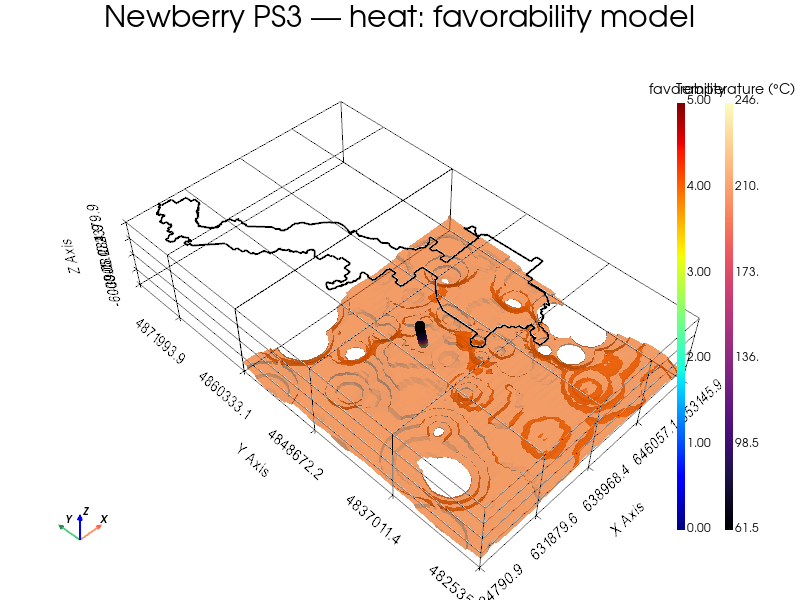

 /Users/ntaverna/Documents/geoPFA General/geoPFA workshop/geoPFA/geopfa/conceptual_modeling.py:471: UserWarning:Failed to use notebook backend "trame": Please install `nest_asyncio2` to automagically launch the trame server without await. Or, to avoid `nest_asyncio2` run:

from pyvista.trame.jupyter import launch_server
await launch_server().ready

Falling back to a static output.
Available backends: "static", "none"
Install trame for interactive backends: pip install "pyvista[jupyter]"


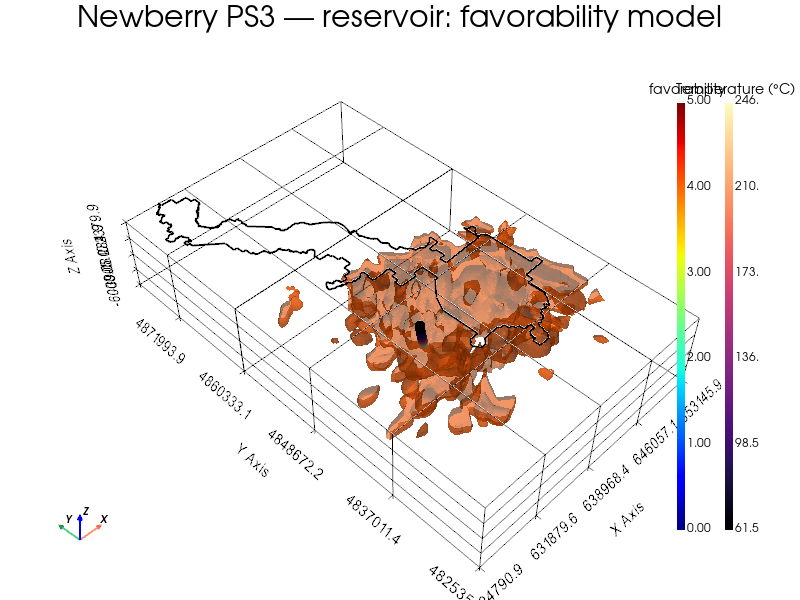

 /Users/ntaverna/Documents/geoPFA General/geoPFA workshop/geoPFA/geopfa/conceptual_modeling.py:471: UserWarning:Failed to use notebook backend "trame": Please install `nest_asyncio2` to automagically launch the trame server without await. Or, to avoid `nest_asyncio2` run:

from pyvista.trame.jupyter import launch_server
await launch_server().ready

Falling back to a static output.
Available backends: "static", "none"
Install trame for interactive backends: pip install "pyvista[jupyter]"


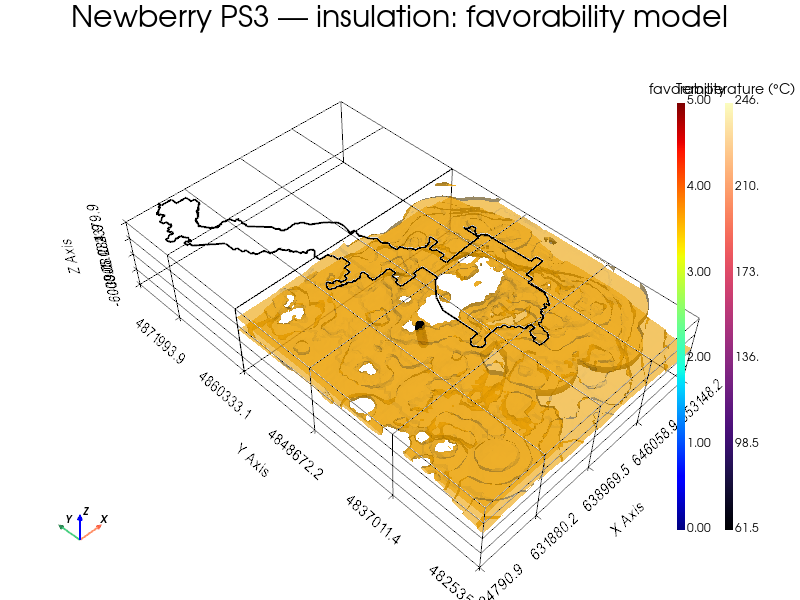

In [8]:
for comp, gdf in components.items():
    ConceptualModeling.plot_isosurface(
        gdf,
        col='favorability',
        units='favorability',
        title=f'Newberry PS3 — {comp}: favorability model',
        contour_level=thresholds[comp],
        area_outline=outline,
        well_path=well_gdf_thinned,
        well_path_values=well_values_thinned,
        extent=extent,
        view=(45, 45),
        off_screen=False,
        window_size=(800, 600),
    )

## 4. Export Filtered Component Models

Export the subset of each component model at or above the 85th-percentile threshold — the same points visible in the isosurface plots above.

In [9]:
filtered_output_dir = output_dir / 'conceptual_model'

for comp, gdf in components.items():
    filtered = gdf[gdf['favorability'] >= thresholds[comp]]
    path = filtered_output_dir / f'{comp}_component_favorability_filtered.csv'
    GeospatialDataWriters.write_csv(filtered, path, target_crs)
    print(f'Exported {len(filtered)} points: {path.name}')

Directory '/Users/ntaverna/Documents/geoPFA General/geoPFA workshop/geoPFA/examples/Newberry/3D/outputs/conceptual_model' created.
Exported 75000 points: heat_component_favorability_filtered.csv
Exported 75000 points: reservoir_component_favorability_filtered.csv
Exported 75000 points: insulation_component_favorability_filtered.csv


## 5. Conceptual Model

All three components are rendered simultaneously as a single conceptual model, providing an integrated view of where heat, reservoir, and insulation favorability overlap in 3D space.

Each component is shown at its 85th-percentile iso-surface:
- **Heat** — pink
- **Reservoir** — light blue
- **Insulation** — yellow

 /Users/ntaverna/Documents/geoPFA General/geoPFA workshop/geoPFA/geopfa/conceptual_modeling.py:806: UserWarning:Failed to use notebook backend "trame": Please install `nest_asyncio2` to automagically launch the trame server without await. Or, to avoid `nest_asyncio2` run:

from pyvista.trame.jupyter import launch_server
await launch_server().ready

Falling back to a static output.
Available backends: "static", "none"
Install trame for interactive backends: pip install "pyvista[jupyter]"


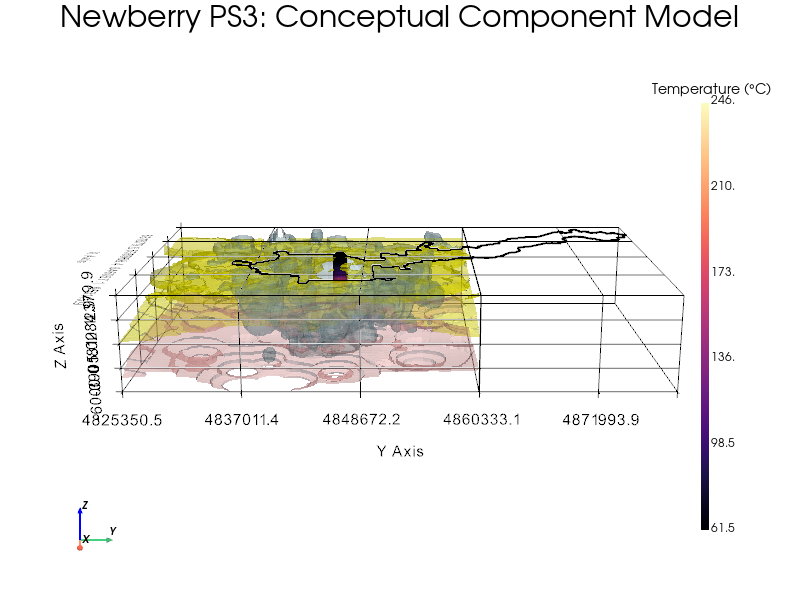

{'grid': ImageData (0x33e4ae440)
   N Cells:      480249
   N Points:     500000
   X Bounds:     6.248e+05, 6.531e+05
   Y Bounds:     4.825e+06, 4.855e+06
   Z Bounds:     -6.000e+03, 2.380e+03
   Dimensions:   100, 100, 50
   Spacing:      2.864e+02, 3.026e+02, 1.710e+02
   N Arrays:     3,
 'grid_clipped': UnstructuredGrid (0x33e4ad300)
   N Cells:    2881494
   N Points:   500000
   X Bounds:   6.248e+05, 6.531e+05
   Y Bounds:   4.825e+06, 4.855e+06
   Z Bounds:   -6.000e+03, 2.380e+03
   N Arrays:   3,
 'iso_components': {'heat_favorability': PolyData (0x33e4aca60)
    N Cells:    128856
    N Points:   65141
    N Strips:   0
    X Bounds:   6.248e+05, 6.531e+05
    Y Bounds:   4.825e+06, 4.855e+06
    Z Bounds:   -6.000e+03, -3.072e+03
    N Arrays:   3,
  'reservoir_favorability': PolyData (0x33e4aca00)
    N Cells:    179870
    N Points:   90722
    N Strips:   0
    X Bounds:   6.248e+05, 6.515e+05
    Y Bounds:   4.830e+06, 4.855e+06
    Z Bounds:   -6.000e+03, 2.380e+03


In [10]:
# Merge all component columns into a single GeoDataFrame
gdf_combined = None
cols = []
for comp, gdf in components.items():
    col_name = f'{comp}_favorability'
    if gdf_combined is None:
        gdf_combined = gdf.rename(columns={'favorability': col_name})
    else:
        gdf_combined[col_name] = gdf['favorability'].values
    cols.append(col_name)

ConceptualModeling.plot_conceptual_model(
    gdf_combined,
    cols,
    units='favorability',
    title='Newberry PS3: Conceptual Component Model',
    contour_levels=[thresholds[c.replace('_favorability', '')] for c in cols],
    area_outline=outline,
    well_path=well_gdf_thinned,
    well_path_values=well_values_thinned,
    extent=extent,
    component_colors=['pink', 'lightblue', 'yellow'],
    view=(15, 180),
    off_screen=False,
    window_size=(800, 600)
)